In [8]:
!pip install sentence-transformers

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sentences = [
# Cricket
"The batsman scored a century in the match",
"The bowler took five wickets in the game",
"The cricket team celebrated their victory",

# Cooking
"I added spices while cooking the curry",
"The chef prepared a delicious pasta dish",
"Baking a cake requires flour, sugar, and eggs",

# Cybersecurity
"Strong passwords help protect online accounts",
"Cybersecurity prevents unauthorized access to systems",
"Phishing attacks try to steal sensitive information",

# Extra sentence
"Network security is important for protecting data"
]

In [11]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of sentences: 10
Embedding shape: (10, 384)


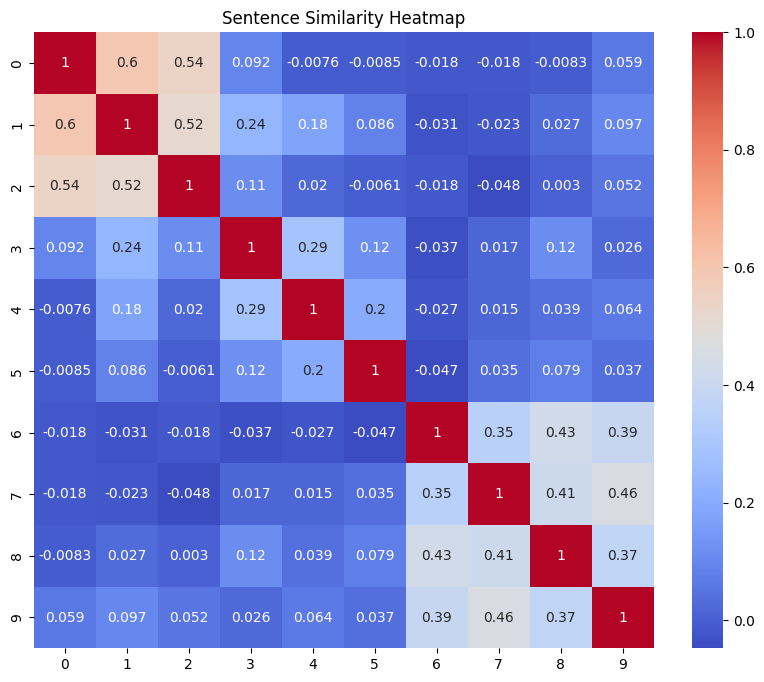

In [12]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")

plt.title("Sentence Similarity Heatmap")
plt.show()

In [13]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for i in top_indices:
    print(sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

The bowler took five wickets in the game
Similarity Score: 0.84704906

The batsman scored a century in the match
Similarity Score: 0.56821966

